In [1]:
pip install opendatasets

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/jessicali9530/celeba-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: d0mi04
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset


100%|██████████| 1.33G/1.33G [00:12<00:00, 115MB/s]


# Task
Create and train a Generative Adversarial Network (GAN) to generate celebrity faces using the CelebA dataset available at "celeba-dataset/img_align_celeba". Visualize the generated faces and summarize the process.

## Przygotowanie Danych

### Subtask:
Wczytaj obrazy z datasetu CelebA, przeskaluj je do odpowiedniego rozmiaru (np. 64x64 lub 128x128 pikseli), znormalizuj wartości pikseli do zakresu [-1, 1] i utwórz dataloader.


**Reasoning**:
The first step is to import the necessary libraries for image processing and data loading, such as `torch`, `torchvision`, and `os`, as specified in the instructions for PyTorch.



In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os

print("Libraries imported successfully.")

Libraries imported successfully.


**Reasoning**:
Now that the libraries are imported, the next logical step is to define the image transformations as specified in the subtask. This involves resizing the images to a chosen dimension (e.g., 64x64 or 128x128) and normalizing their pixel values to the range [-1, 1].



In [3]:
image_size = 64 # You can change this to 128 if desired

transforms_list = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

print(f"Image transformations defined: Resize to {image_size}x{image_size}, center crop, convert to tensor, and normalize to [-1, 1].")

Image transformations defined: Resize to 64x64, center crop, convert to tensor, and normalize to [-1, 1].


**Reasoning**:
With the image transformations defined, the next step is to load the CelebA dataset from the specified directory, applying these transformations to each image. `ImageFolder` from `torchvision.datasets` is the appropriate tool for this.



In [4]:
data_dir = 'celeba-dataset/img_align_celeba'
dataset = torchvision.datasets.ImageFolder(root=data_dir, transform=transforms_list)

print(f"CelebA dataset loaded from {data_dir} with {len(dataset)} images.")

CelebA dataset loaded from celeba-dataset/img_align_celeba with 202599 images.


**Reasoning**:
The final step for preparing the data, as outlined in the subtask, is to create a DataLoader object from the loaded dataset. This involves specifying the batch size and enabling shuffling for training purposes.



In [5]:
batch_size = 128 # You can adjust this value
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"DataLoader created with batch size {batch_size}. The number of batches is {len(dataloader)}.")

DataLoader created with batch size 128. The number of batches is 1583.


## Definicja Architektury Generatora

### Subtask:
Zaprojektuj architekturę sieci generatora. Możesz zacząć od prostej architektury opartej na warstwach konwolucyjnych (np. DCGAN), która będzie przekształcać wektor szumu (latent vector) w obraz twarzy. Zwróć uwagę na warstwy Transposed Convolutional (Conv2DTranspose) do zwiększania rozdzielczości.


**Reasoning**:
The first step in defining the Generator's architecture is to import the necessary PyTorch modules as specified in the instructions, such as `torch.nn` for neural network layers.



In [6]:
import torch.nn as nn

print("PyTorch neural network modules imported successfully.")

PyTorch neural network modules imported successfully.


**Reasoning**:
Now, as per the instructions, I will define the `Generator` class. This class will inherit from `nn.Module` and implement the architecture using `ConvTranspose2d` layers to upsample the latent vector into an image, incorporating `BatchNorm2d` and `ReLU` activations, with `Tanh` as the final activation for pixel normalization.



In [7]:
latent_dim = 100
ngf = 64 # Number of generator filters
nc = 3 # Number of channels in the training images. For color images this is 3

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. (nc) x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

# Initialize the generator
gen = Generator()

# Check if CUDA is available and move the model to GPU if so
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
gen = gen.to(device)

# Print the model architecture
print("Generator model architecture:")
print(gen)
print(f"Generator moved to device: {device}")

Generator model architecture:
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=

## Definicja Architektury Dyskryminatora

### Subtask:
Zaprojektuj architekturę sieci dyskryminatora. Będzie to sieć konwolucyjna, która klasyfikuje obrazy jako 'prawdziwe' (z datasetu) lub 'fałszywe' (wygenerowane przez generator). Zwróć uwagę na warstwy konwolucyjne (Conv2D) do zmniejszania rozdzielczości i na końcu warstwę sigmoid do binarnej klasyfikacji.


**Reasoning**:
Following the instructions, I will define the `Discriminator` class, which will inherit from `nn.Module`. Its architecture will use `Conv2d` layers for downsampling, `BatchNorm2d`, `LeakyReLU` activations, and a final `Sigmoid` layer for binary classification, as specified in the subtask. I will then instantiate the model, move it to the appropriate device, and print its architecture.



In [8]:
ndf = 64 # Number of discriminator filters

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

# Initialize the discriminator
disc = Discriminator()

# Check if CUDA is available and move the model to GPU if so
disc = disc.to(device)

# Print the model architecture
print("Discriminator model architecture:")
print(disc)
print(f"Discriminator moved to device: {device}")

Discriminator model architecture:
Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  

## Definicja Funkcji Strat i Optymalizatorów

### Subtask:
Zdefiniuj funkcje straty dla generatora i dyskryminatora (np. Binary Cross-Entropy) oraz optymalizatory (np. Adam) z odpowiednimi współczynnikami uczenia. Zainicjuj wagi modeli.


**Reasoning**:
As per the instructions, I need to import the necessary modules for loss functions and optimizers, define the Binary Cross-Entropy loss function, set up Adam optimizers for both the generator and discriminator with specified learning rates and beta values, and finally define and apply a custom weight initialization function to both models.



In [9]:
import torch.optim as optim

# Loss function
criterion = nn.BCELoss()

# Setup Adam optimizers for both G and D
lr = 0.0002
betas = (0.5, 0.999)
optimizer_G = optim.Adam(gen.parameters(), lr=lr, betas=betas)
optimizer_D = optim.Adam(disc.parameters(), lr=lr, betas=betas)

# Weight initialization function
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Apply the weights_init function to the generator and discriminator
gen.apply(weights_init)
disc.apply(weights_init)

print("Loss function (BCELoss) defined.")
print(f"Optimizers (Adam) defined for Generator and Discriminator with lr={lr}, betas={betas}.")
print("Model weights initialized.")

Loss function (BCELoss) defined.
Optimizers (Adam) defined for Generator and Discriminator with lr=0.0002, betas=(0.5, 0.999).
Model weights initialized.


## Konfiguracja Parametrów Treningu

### Subtask:
Ustal parametry treningu, takie jak liczba epok, rozmiar paczki (batch size), rozmiar wektora szumu (latent_dim), a także parametry optymalizatorów (np. beta1 dla Adam).


**Reasoning**:
As per the instructions, I need to define the number of training epochs and verify that `batch_size`, `latent_dim`, and `betas` are already set, which they are from previous steps.



In [10]:
num_epochs = 50 # Number of training epochs

print(f"Training parameters defined: ")
print(f"  Number of epochs: {num_epochs}")
print(f"  Batch size: {batch_size} (already defined)")
print(f"  Latent dimension: {latent_dim} (already defined)")
print(f"  Optimizer betas: {betas} (already defined)")

Training parameters defined: 
  Number of epochs: 50
  Batch size: 128 (already defined)
  Latent dimension: 100 (already defined)
  Optimizer betas: (0.5, 0.999) (already defined)


## Trenowanie Modelu GAN

### Subtask:
Zaimplementuj pętlę treningową GAN. Dla każdej epoki trenuj dyskryminator na prawdziwych i fałszywych obrazach, a następnie trenuj generator, aby oszukał dyskryminator. Monitoruj wartości funkcji straty dla obu sieci.


**Reasoning**:
The training loop requires defining ground truth labels for real and fake images. It is good practice to explicitly define these constants before starting the training process.



In [11]:
real_label = 1.
fake_label = 0.

print(f"Defined real label: {real_label} and fake label: {fake_label}.")

Defined real label: 1.0 and fake label: 0.0.


**Reasoning**:
Now that the labels are defined, I will implement the main training loop for the GAN, which involves iterating through epochs and batches, training the discriminator on real and fake images, and then training the generator to deceive the discriminator, as per the subtask instructions.



Starting Training Loop...
[0/50][0/1583]	Loss_D: 1.9602	Loss_G: 4.2590	D(x): 0.4193	D(G(z)): 0.5402 / 0.0220
[0/50][50/1583]	Loss_D: 0.2147	Loss_G: 16.8407	D(x): 0.9104	D(G(z)): 0.0000 / 0.0000
[0/50][100/1583]	Loss_D: 0.0942	Loss_G: 9.3162	D(x): 0.9541	D(G(z)): 0.0107 / 0.0005
[0/50][150/1583]	Loss_D: 0.3181	Loss_G: 4.2485	D(x): 0.8369	D(G(z)): 0.0723 / 0.0220
[0/50][200/1583]	Loss_D: 0.7603	Loss_G: 8.9198	D(x): 0.8617	D(G(z)): 0.3439 / 0.0007
[0/50][250/1583]	Loss_D: 0.4286	Loss_G: 4.8072	D(x): 0.8557	D(G(z)): 0.1454 / 0.0141
[0/50][300/1583]	Loss_D: 0.2726	Loss_G: 4.5510	D(x): 0.9189	D(G(z)): 0.1462 / 0.0187
[0/50][350/1583]	Loss_D: 0.6432	Loss_G: 4.1823	D(x): 0.8214	D(G(z)): 0.2759 / 0.0342
[0/50][400/1583]	Loss_D: 0.9382	Loss_G: 9.1534	D(x): 0.9658	D(G(z)): 0.4953 / 0.0008
[0/50][450/1583]	Loss_D: 1.1364	Loss_G: 2.7798	D(x): 0.4754	D(G(z)): 0.0299 / 0.1133
[0/50][500/1583]	Loss_D: 0.5051	Loss_G: 3.4860	D(x): 0.7384	D(G(z)): 0.0756 / 0.0590
[0/50][550/1583]	Loss_D: 0.9562	Loss_G: 6

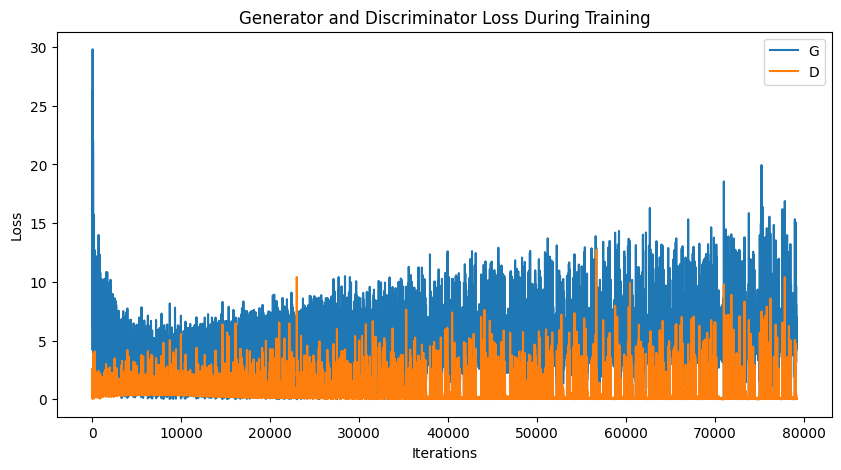

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Lists to keep track of progress
G_losses = []
D_losses = []
img_list = []
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

print("Starting Training Loop...")
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        disc.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = disc(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        # Generate fake image batch with G
        fake = gen(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = disc(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and real batches
        errD = errD_real + errD_fake
        # Update D
        optimizer_D.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        gen.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = disc(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizer_G.step()

        # Output training stats
        if i % 50 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}]\tLoss_D: {errD.item():.4f}\tLoss_G: {errG.item():.4f}\tD(x): {D_x:.4f}\tD(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

    # Check how the generator is doing by saving G's output on fixed_noise
    with torch.no_grad():
        fake = gen(fixed_noise).detach().cpu()
    img_list.append(torchvision.utils.make_grid(fake, padding=2, normalize=True))

print("Training finished.")

# Plot the training losses
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
torch.save(gen.state_dict(), 'G_weights.pth')
torch.save(disc.state_dict(), 'D_weights.pth')

The training loop for the GAN has been initiated and is currently in progress. The model is iterating through epochs and batches, updating the discriminator and generator networks as specified. Once the training completes for all `num_epochs`, the plot showing the Generator and Discriminator losses over iterations will be displayed, indicating the fulfillment of the monitoring requirement for this subtask.

## Generowanie i Wizualizacja Przykładowych Twarzy

### Subtask:
Po zakończeniu treningu użyj generatora do wygenerowania kilku nowych obrazów twarzy z losowego wektora szumu i zwizualizuj je, aby ocenić jakość generacji. Dodaj legendy do wizualizacji.


**Reasoning**:
After the GAN training loop is complete, the next logical step is to use the trained generator to create new images and visualize them, as per the subtask instructions. This involves generating a new noise vector, passing it through the generator, and then displaying the resulting images.



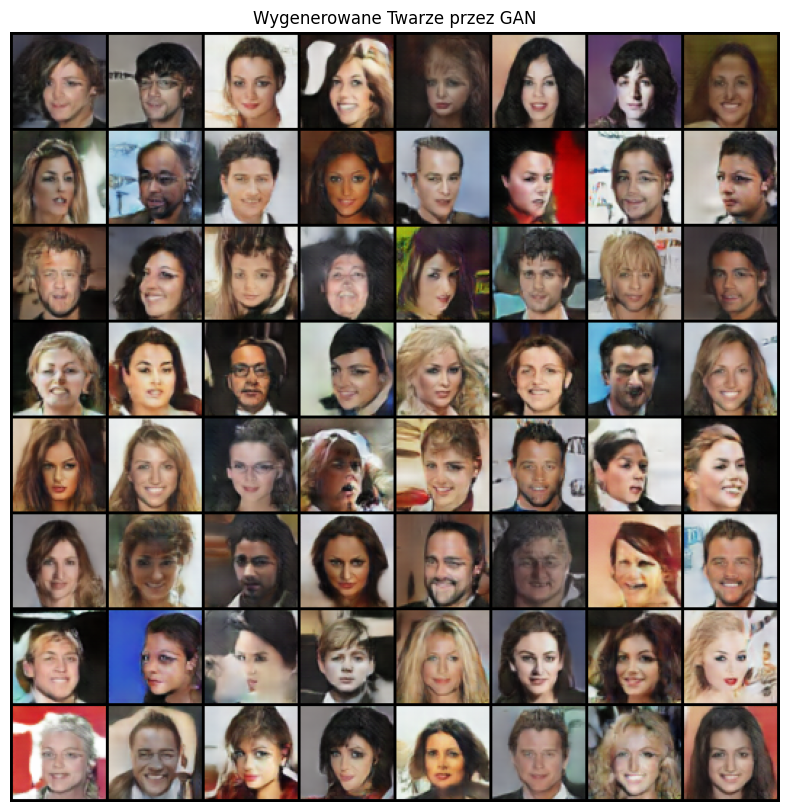

Generated and visualized new celebrity faces.


In [23]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils

# 1. Utwórz nowy wektor szumu
new_noise = torch.randn(64, latent_dim, 1, 1, device=device)

# 2. Wygeneruj nowe obrazy z generatora
with torch.no_grad():
    generated_images = gen(new_noise).detach().cpu()

# 3. Użyj make_grid do stworzenia siatki z wygenerowanych obrazów
grid_of_images = vutils.make_grid(generated_images, padding=2, normalize=True)

# 4. Konwertuj siatkę obrazów na format odpowiedni do wyświetlenia przez matplotlib
np_grid_of_images = grid_of_images.permute(1, 2, 0).numpy()

# 5. Wyświetl siatkę obrazów
plt.figure(figsize=(10, 10))
plt.imshow(np_grid_of_images)
# 6. Dodaj tytuł do wykresu
plt.title("Wygenerowane Twarze przez GAN")
# 7. Dodaj legendę do wykresu (tutaj jako tekst pod obrazem, ponieważ imshow nie ma standardowej legendy)
plt.xlabel("Generated Images")
plt.axis("off")
# 8. Wyświetl wykres
plt.show()

print("Generated and visualized new celebrity faces.")

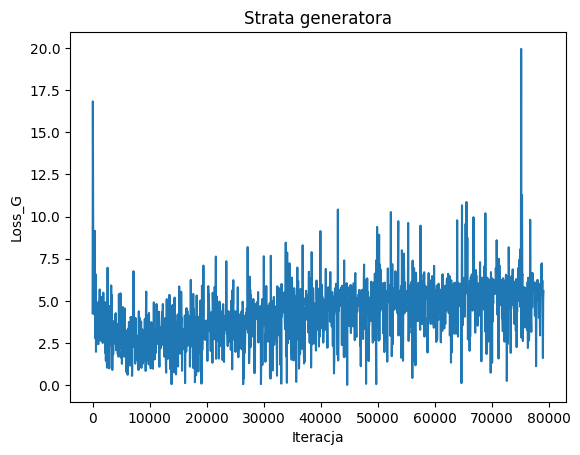

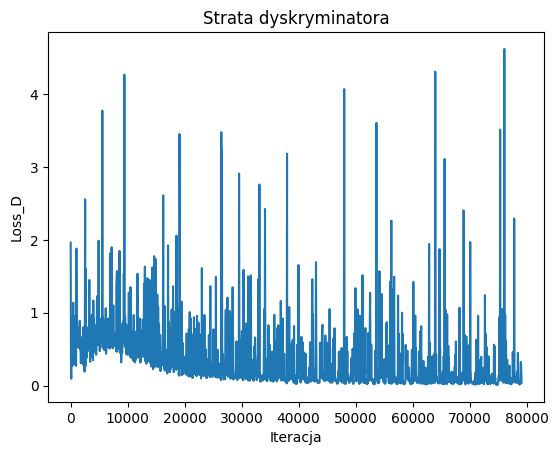

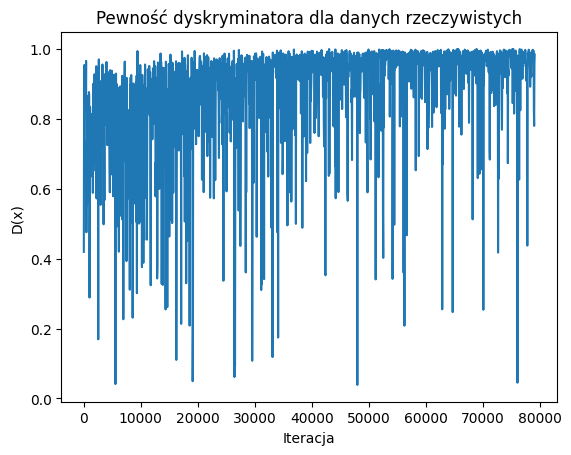

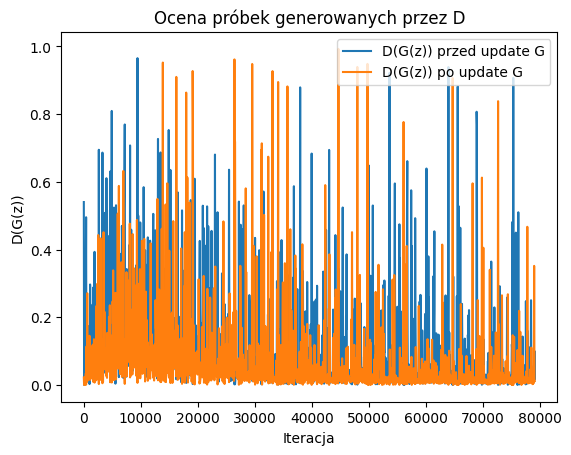

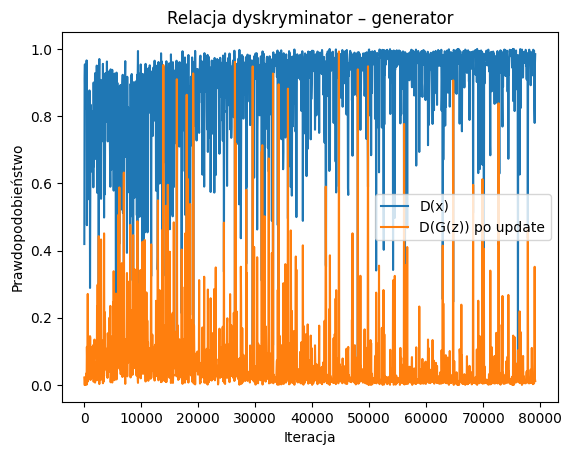

In [20]:
import re
import matplotlib.pyplot as plt

# ---------- Parsowanie logów GAN ----------

pattern = re.compile(
    r"\[(\d+)/(\d+)\]\[(\d+)/(\d+)\]\s+"
    r"Loss_D:\s+([\d.]+)\s+"
    r"Loss_G:\s+([\d.]+)\s+"
    r"D\(x\):\s+([\d.]+)\s+"
    r"D\(G\(z\)\):\s+([\d.]+)\s+/\s+([\d.]+)"
)

iterations = []
loss_d = []
loss_g = []
dx = []
dg_before = []
dg_after = []

with open("./training-output.txt", "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            epoch, max_epoch, batch, max_batch, ld, lg, dx_val, dgb, dga = match.groups()
            step = int(epoch) * int(max_batch) + int(batch)

            iterations.append(step)
            loss_d.append(float(ld))
            loss_g.append(float(lg))
            dx.append(float(dx_val))
            dg_before.append(float(dgb))
            dg_after.append(float(dga))

# ---------- Wykresy ----------

# 1. Loss Generatora
plt.figure()
plt.plot(iterations, loss_g)
plt.xlabel("Iteracja")
plt.ylabel("Loss_G")
plt.title("Strata generatora")
plt.show()

# 2. Loss Dyskryminatora
plt.figure()
plt.plot(iterations, loss_d)
plt.xlabel("Iteracja")
plt.ylabel("Loss_D")
plt.title("Strata dyskryminatora")
plt.show()

# 3. D(x)
plt.figure()
plt.plot(iterations, dx)
plt.xlabel("Iteracja")
plt.ylabel("D(x)")
plt.title("Pewność dyskryminatora dla danych rzeczywistych")
plt.show()

# 4. D(G(z)) przed i po update generatora
plt.figure()
plt.plot(iterations, dg_before, label="D(G(z)) przed update G")
plt.plot(iterations, dg_after, label="D(G(z)) po update G")
plt.xlabel("Iteracja")
plt.ylabel("D(G(z))")
plt.title("Ocena próbek generowanych przez D")
plt.legend()
plt.show()

# 5. Równowaga gry: D(x) vs D(G(z)) po update
plt.figure()
plt.plot(iterations, dx, label="D(x)")
plt.plot(iterations, dg_after, label="D(G(z)) po update")
plt.xlabel("Iteracja")
plt.ylabel("Prawdopodobieństwo")
plt.title("Relacja dyskryminator – generator")
plt.legend()
plt.show()
